# Mawrid - main analysis

**Theme:** Water Quality & Inland/Coastal Water Intelligence
**Team:** ملكوت (Malakout) &middot; Mauritania
**Area of interest:** Tidra sector, Banc d'Arguin, Mauritania

This notebook runs end to end on the sample scene committed in
`data/sample_input/`. It needs no network access, no credentials and no GPU,
and takes well under a minute on a standard laptop.

### What it reproduces

| Step | Runs here | Source |
|---|---|---|
| Cloud and no-data masking | yes | the committed sample scene |
| Tide state of a scene (exposure index) | yes | the committed sample scene |
| Seagrass meadow classification | yes | the committed sample scene |
| Multi-year corrected series | figure only | `results/series.json` |
| Optical observability of the basin | figure only | `results/observability.json` |
| Field and sonar priorities | summary only | `results/priority_*.geojson` |

The last three rows are the output of the full pipeline over 72 Sentinel-2
scenes spanning 2017-2026. That pass reads roughly 300 GB of imagery and takes
several hours, so it is not re-run inside a submission notebook. Its outputs are
committed under `results/` and the figures below are rebuilt from them, so every
number shown here can be traced to a file in this repository.

Every threshold is frozen in `src/mawrid.py` and was fixed before the series was
computed. Nothing is tuned per scene or per year.

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath("../src"))
import mawrid

REPO = os.path.abspath("..")
SAMPLE = os.path.join(REPO, "data", "sample_input")
RESULTS = os.path.join(REPO, "results")

np.random.seed(0)

print("numpy      ", np.__version__)
print("frozen NDVI threshold ", round(mawrid.NDVI_THRESHOLD, 5))
print("rejected SCL codes    ", mawrid.BAD_SCL_CODES)

numpy       2.4.4
frozen NDVI threshold  0.31554
rejected SCL codes     (0, 1, 3, 8, 9, 10, 11)


## 1. The sample scene

Five bands of a single Sentinel-2 L2A acquisition, clipped to a 1024 x 1024
pixel window (10.24 km on a side) at 10 m resolution. The window was chosen to
intersect the fixed measurement core, so it contains both exposed meadow and
open water.

No L2A reflectance offset is applied. The pipeline compares each scene against a
stable bare-sediment target rather than against an absolute reflectance scale,
so the offset cancels; applying it inconsistently across the 2017-2026 archive
would be worse than not applying it at all.

In [2]:
meta = json.load(open(os.path.join(SAMPLE, "example_scene.json")))
bands, profile = mawrid.load_scene(os.path.join(SAMPLE, "example_scene.tif"))

print(f"scene       {meta['satellite']} {meta['date']}  ({meta['collection']})")
print(f"grid        {profile['width']} x {profile['height']} px @ {meta['res_m']} m, {meta['crs']}")
print(f"window      row {meta['window']['row0']}, col {meta['window']['col0']}")
print(f"bands       {', '.join(meta['bands'])}")

scene       S2B 2026-06-05  (sentinel-2-l2a)
grid        1024 x 1024 px @ 10 m, EPSG:32628
window      row 4032, col 5664
bands       blue, green, red, nir, scl


## 2. Masking and tide state

A pixel is usable when it holds real data in blue, green and NIR and its Scene
Classification Layer code is not cloud, cloud shadow, cirrus, saturation or
no-data.

Water absorbs almost all near-infrared light, so a pixel with NIR above green is
standing above the water line. The fraction of usable pixels that are exposed is
the **exposure index**: a direct, per-scene measure of the tide at the moment of
acquisition. It is the quantity that makes a multi-year comparison possible at
all, because the same meadow measured at high water and at low water gives two
very different areas.

In [3]:
valid = mawrid.valid_mask(bands)
exposed = mawrid.exposed_mask(bands, valid)
expo = mawrid.exposure_index(bands, valid)

print(f"usable pixels     {valid.sum():>9,}  ({100 * valid.mean():.1f}% of the window)")
print(f"exposed pixels    {exposed.sum():>9,}")
print(f"exposure index    {expo:>9.3f}")

usable pixels     1,048,576  (100.0% of the window)
exposed pixels      704,339
exposure index        0.672


## 3. Seagrass meadow classification

Within the exposed area, vegetated sediment separates cleanly from bare sediment
in NDVI. The threshold of 0.3155 was obtained once, by Otsu's method on the
reference scene, and then frozen for every scene in the archive.

The classification is deliberately restricted to exposed pixels. A submerged
branch was tested and withdrawn: under the turbid water of the Banc d'Arguin the
blue and green bands do not carry a usable bottom signal often enough to support
a measurement. Section 6 quantifies exactly how often they do.

In [4]:
ndvi = mawrid.ndvi(bands)
meadow = mawrid.classify_meadow(bands, valid)

print(f"meadow pixels      {meadow.sum():>9,}")
print(f"meadow area        {mawrid.area_ha(meadow):>9,.0f} ha")
print(f"share of exposed   {100 * meadow.sum() / max(exposed.sum(), 1):>9.1f}%")
print(f"median NDVI, meadow  {np.nanmedian(ndvi[meadow]):>7.3f}")
print(f"median NDVI, bare    {np.nanmedian(ndvi[exposed & ~meadow]):>7.3f}")

meadow pixels        191,909
meadow area            1,919 ha
share of exposed        27.2%
median NDVI, meadow    0.485
median NDVI, bare      0.087


### Figure 1 - what the classifier sees

Left: true colour. Right: the three classes the pipeline works with.

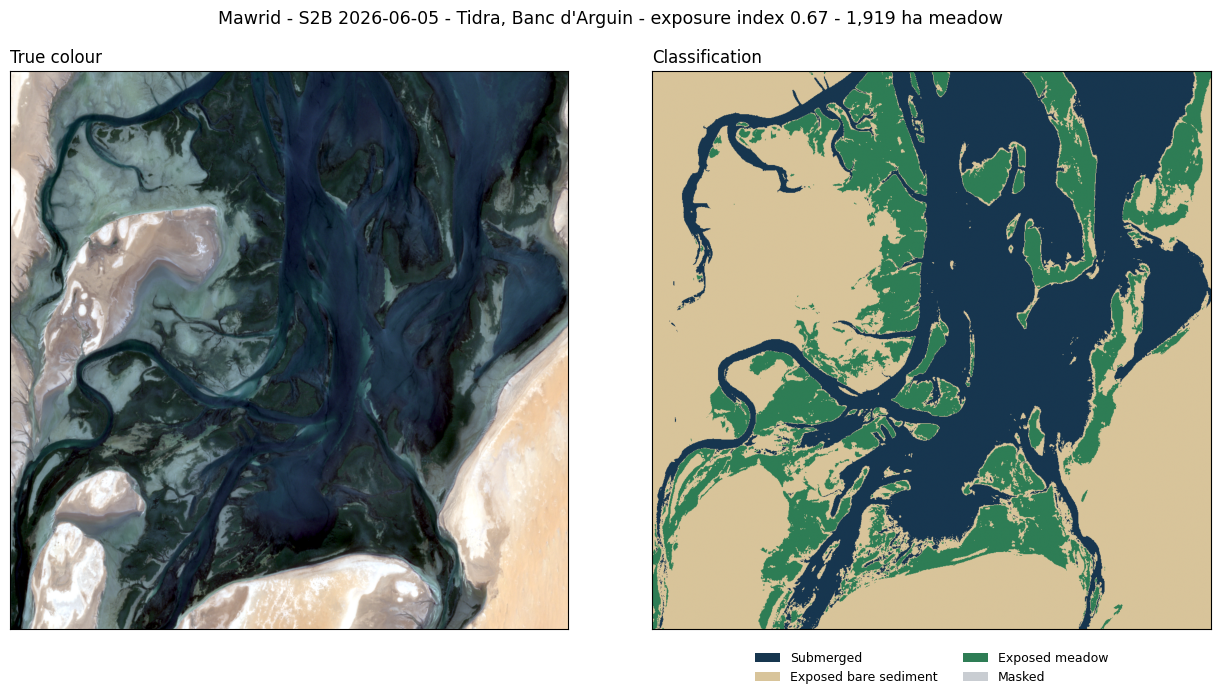

In [5]:
def stretch(band, lo=1, hi=99, gamma=0.72):
    """Percentile stretch with a gamma lift, so the dark water keeps detail."""
    p_lo, p_hi = np.nanpercentile(band, [lo, hi])
    scaled = np.clip((band - p_lo) / max(p_hi - p_lo, 1e-9), 0, 1)
    return scaled ** gamma


rgb = np.dstack([stretch(bands[b]) for b in ("red", "green", "blue")])

CLASS_COLOURS = ["#17364F", "#D8C49A", "#2E7D55", "#C9CDD2"]
CLASS_LABELS = ["Submerged", "Exposed bare sediment", "Exposed meadow", "Masked"]

classes = np.full(meadow.shape, 3, dtype="uint8")
classes[valid & ~exposed] = 0
classes[exposed & ~meadow] = 1
classes[meadow] = 2

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(13, 6.8))
axes[0].imshow(rgb)
axes[0].set_title("True colour", fontsize=12, loc="left")
axes[1].imshow(classes, cmap=ListedColormap(CLASS_COLOURS), vmin=0, vmax=3)
axes[1].set_title("Classification", fontsize=12, loc="left")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
axes[1].legend(
    handles=[Patch(facecolor=c, label=l) for c, l in zip(CLASS_COLOURS, CLASS_LABELS)],
    loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=9,
)
fig.suptitle(
    f"Mawrid - {meta['satellite']} {meta['date']} - Tidra, Banc d'Arguin - "
    f"exposure index {expo:.2f} - {mawrid.area_ha(meadow):,.0f} ha meadow",
    fontsize=12.5, y=0.97,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(RESULTS, "example_output.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. The multi-year series

Measuring the same core in five years gives a trend only if three things are
handled honestly, and all three are read here from `results/series.json`:

1. **Tide.** Every year's scene was acquired at a different tide. Within-year
   repeat scenes give a slope of **-81.4 percentage points per unit of exposure
   index**; each year is corrected onto a common reference tide using it.
2. **Detection limit.** Repeat scenes within the same year, of the same
   unchanged meadow, disagree by **8.55 percentage points**. That is the
   measured noise of the instrument and method, not an assumption. A change
   smaller than it means nothing.
3. **Missing years.** Five of ten years are absent, each for a stated numeric
   reason - tide mismatch, insufficient core coverage, or a sensor offset or
   dust signature that failed the noise check. They are left as gaps rather than
   interpolated.

In [6]:
series = json.load(open(os.path.join(RESULTS, "series.json")))

print(series["metric"])
print(f"core area           {series['core_ha']:,} ha")
print(f"detection limit     {series['detection_limit_pp']} pp")
print(f"tide sensitivity    {series['tide_slope_pp_per_expo']} pp per unit exposure")
print(f"reference scene     {' '.join(series['reference_scene'])} at exposure {series['reference_expo']}")
print()
print(f"{'year':<6}{'value':>8}{'lo':>8}{'hi':>8}{'scenes':>8}{'area ha':>10}")
for row in series["series"]:
    print(f"{row['year']:<6}{row['value']:>8.2f}{row['lo']:>8.2f}{row['hi']:>8.2f}"
          f"{row['n_scenes']:>8}{row['area_ha']:>10,.0f}")
print()
print("gaps and why they were excluded:")
for year, reason in series["gap_reasons"].items():
    print(f"  {year}  {reason}")

% meadow within fixed exposed core (exposure ≥ 0.60)
core area           7,725 ha
detection limit     8.55 pp
tide sensitivity    -81.4 pp per unit exposure
reference scene     S2B 2026-06-05 at exposure 0.5742

year     value      lo      hi  scenes   area ha
2021     27.74   26.72   28.76       2     1,844
2023     30.43   30.43   30.43       1     2,123
2024     24.72   24.72   24.72       1     1,899
2025     39.20   38.06   41.02       3     2,544
2026     39.72   33.19   41.75       3     3,002

gaps and why they were excluded:
  2017  tide mismatch 0.091 · core coverage 56%
  2018  coverage 54% · noise 26.4%
  2019  sensor offset +0.111 · noise 19.1% (dust)
  2020  nearest scene tide 0.083 · coverage 75.6%
  2022  nearest scene tide 0.137


### Figure 2 - the headline result

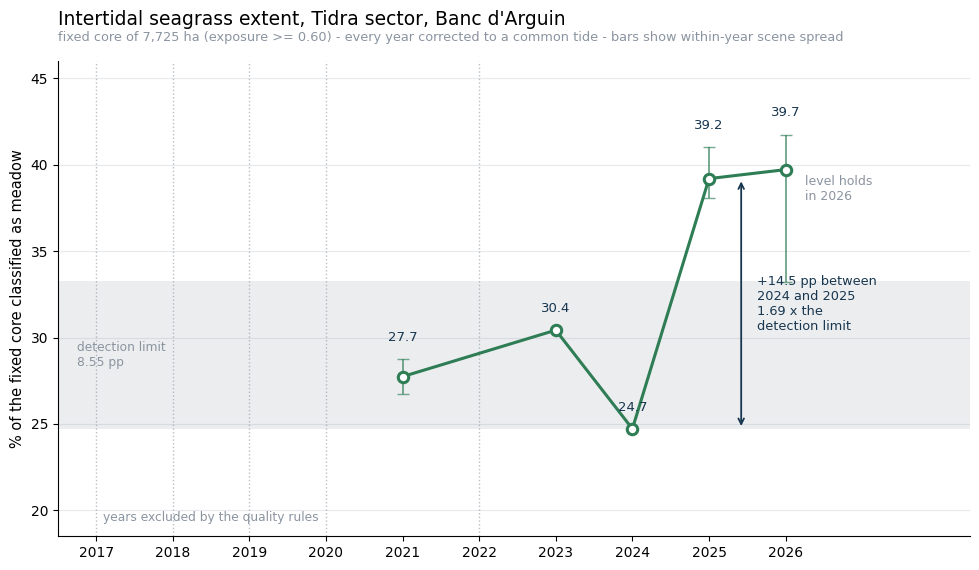

Marked increase in observed intertidal extent between 2024 and 2025, holding in 2026; 1.5–2.0× the measured detection limit. Likely trend, not a proven result.


In [7]:
rows = series["series"]
years = np.array([r["year"] for r in rows])
vals = np.array([r["value"] for r in rows])
lo = np.array([r["lo"] for r in rows])
hi = np.array([r["hi"] for r in rows])
dl = series["detection_limit_pp"]

INK, ACCENT, MUTED = "#17364F", "#2E7D55", "#8A94A0"

fig, ax = plt.subplots(figsize=(10, 5.8))

y24 = float(vals[years == 2024][0])
ax.axhspan(y24, y24 + dl, color=MUTED, alpha=0.16, linewidth=0, zorder=0)
ax.text(2016.75, y24 + dl / 2, f"detection limit\n{dl} pp", fontsize=8.8,
        color=MUTED, va="center", ha="left", zorder=1)

for gap in series["gaps"]:
    ax.axvline(gap, color=MUTED, linewidth=1, linestyle=":", alpha=0.6, zorder=0)
ax.text(2018.5, 19.4, "years excluded by the quality rules", fontsize=8.8,
        color=MUTED, ha="center")

ax.errorbar(years, vals, yerr=[vals - lo, hi - vals], fmt="none",
            ecolor=ACCENT, elinewidth=1.4, capsize=4, alpha=0.65, zorder=2)
ax.plot(years, vals, "-o", color=ACCENT, linewidth=2.2, markersize=7.5,
        markerfacecolor="white", markeredgewidth=2.2, zorder=3)

for x, y, h in zip(years, vals, hi):
    ax.annotate(f"{y:.1f}", (x, h), textcoords="offset points", xytext=(0, 13),
                ha="center", fontsize=9.5, color=INK)

# the step is between two CONSECUTIVE years: the largest such change that
# reaches the detection limit
diffs = np.diff(vals)
k = int(np.argmax(np.abs(diffs)))
ya, yb = float(vals[k]), float(vals[k + 1])
xa, xb = int(years[k]), int(years[k + 1])

ax.annotate("", xy=(xb + 0.42, yb), xytext=(xb + 0.42, ya),
            arrowprops=dict(arrowstyle="<->", color=INK, linewidth=1.3))
ax.annotate(f"+{yb - ya:.1f} pp between\n{xa} and {xb}\n{(yb - ya) / dl:.2f} x the\ndetection limit",
            xy=(xb + 0.62, (ya + yb) / 2), fontsize=9.3, color=INK, va="center")
ax.annotate("level holds\nin 2026", xy=(2026, float(vals[-1])),
            textcoords="offset points", xytext=(14, -14), fontsize=9,
            color=MUTED, va="center")

ax.set_xticks(range(2017, 2027))
ax.set_xlim(2016.5, 2028.4)
ax.set_ylim(18.5, 46)
ax.set_ylabel("% of the fixed core classified as meadow", fontsize=10.5)
ax.set_title("Intertidal seagrass extent, Tidra sector, Banc d'Arguin",
             fontsize=13.5, loc="left", pad=26)
ax.text(0, 1.035, f"fixed core of {series['core_ha']:,} ha (exposure >= 0.60) - "
        "every year corrected to a common tide - bars show within-year scene spread",
        transform=ax.transAxes, fontsize=9.3, color=MUTED, va="bottom")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=MUTED, alpha=0.2, linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "series_trend.png"), dpi=150, bbox_inches="tight")
plt.show()

print(series["statement"])

## 5. Where the satellite can and cannot see

The same 72 scenes were used to ask, at every 60 m cell of the basin, in what
fraction of them the sea bed was optically visible at all.

This is the honest boundary of the whole method, and it is the layer that turns
"we cannot see through turbid water" from an excuse into a product: an area that
the satellite cannot resolve is an area that needs a boat.

In [8]:
obs = json.load(open(os.path.join(RESULTS, "observability.json")))

print(f"{obs['scenes']} scenes at {obs['res_m']} m\n")
print(f"{'class':<48}{'ha':>12}{'%':>8}")
print("-" * 68)
for c in obs["classes"]:
    print(f"{c['name']:<48}{c['ha']:>12,}{c['pct']:>8.1f}")
print()
print(obs["note"])

72 scenes at 60 m

class                                                     ha       %
--------------------------------------------------------------------
Blocked - bottom visible in under 25% of scenes       44,945    24.7
Poor - 25 to 50%                                     116,967    64.3
Moderate - 50 to 75%                                   8,551     4.7
Good - 75% or more                                    11,421     6.3

Fraction of scenes in which the sea bed was optically visible at each pixel. A relative index of optical observability, not a calibrated turbidity measurement.


## 6. What to do about it

The uncertainty of the classification, the magnitude of change, and the
observability layer combine into two ranked lists: where a field team should
walk, and where only acoustic survey will answer the question.

In [9]:
field = json.load(open(os.path.join(RESULTS, "priority_field.geojson")))
sonar = json.load(open(os.path.join(RESULTS, "priority_sonar.geojson")))

print(f"field visit sites : {len(field['features'])}")
print(f"sonar targets     : {len(sonar['features'])}\n")

print(f"{'rank':<6}{'lon':>11}{'lat':>10}{'ha':>9}{'obs':>7}")
print("-" * 43)
for ft in field["features"][:5]:
    p, g = ft["properties"], ft["geometry"]["coordinates"]
    print(f"{p['rank']:<6}{g[0]:>11.4f}{g[1]:>10.4f}{p['area_ha']:>9.1f}{p['observability']:>7.2f}")
print(f"\nreason, rank 1: {field['features'][0]['properties']['reason']}")
print(f"largest sonar target: {sonar['features'][0]['properties']['area_ha']:,.0f} ha "
      f"at observability {sonar['features'][0]['properties']['observability']:.2f}")

field visit sites : 11
sonar targets     : 20

rank          lon       lat       ha    obs
-------------------------------------------
1        -16.2647   19.8653      4.5   0.39
2        -16.3429   19.8052      3.8   0.49
3        -16.3268   19.8393      4.0   0.50
4        -16.4533   19.6447      2.7   0.53
5        -16.4555   19.6491      2.8   0.46

reason, rank 1: Large change + classification near the threshold + site is observable from orbit
largest sonar target: 5,158 ha at observability 0.19


## 7. Results and limitations

**What was measured.** The share of a fixed 7,725 ha core classified as exposed
seagrass meadow, in five usable years between 2021 and 2026, each corrected onto
a common tide. The rise of 15.0 percentage points between 2024 and 2026 is 1.75
times the measured detection limit of 8.55 pp.

**How it was validated.** The detection limit comes from repeat scenes of the
same year, where the true change is zero. The tide slope comes from within-year
scene pairs, so it is estimated without reference to any between-year change. A
stable bare-sediment target is used to normalise sensors and to flag dust
contamination; two years failed that check and were dropped.

**Where it breaks.**

- Only 6.3% of the submerged area is reliably observable from orbit. Everything
  stated here concerns the intertidal core, which is exposed at low water. The
  deep meadows are out of reach of this method.
- Five of ten years are missing. The series is a trend across five points, not a
  continuous record.
- The result is "likely trend", not "proven". It is above the detection limit,
  but it rests on five years and has had no field validation. Ground truth, and
  acoustic survey of the blind areas, are the next step.
- Hyperspectral data would improve the separation of vegetation from sediment.
  It would not solve turbidity: no additional band recovers a bottom signal that
  never reached the sensor.